In [74]:
import pandas as pd
import os

# Load the data 

In [75]:
df = pd.read_csv("dataset/babies.csv")
df.head()

,case,bwt,gestation,parity,age,height,weight,smoke
0,1,120,284.0,0,27.0,62.0,100.0,0.0
1,2,113,282.0,0,33.0,64.0,135.0,0.0
2,3,128,279.0,0,28.0,64.0,115.0,1.0
3,4,123,NaN,0,36.0,69.0,190.0,0.0
4,5,108,282.0,0,23.0,67.0,125.0,1.0


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   case       1236 non-null   int64  
 1   bwt        1236 non-null   int64  
 2   gestation  1223 non-null   float64
 3   parity     1236 non-null   int64  
 4   age        1234 non-null   float64
 5   height     1214 non-null   float64
 6   weight     1200 non-null   float64
 7   smoke      1226 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 77.4 KB


In [77]:
df.describe()

,case,bwt,gestation,parity,age,height,weight,smoke
count,1236.000000,1236.000000,1223.000000,1236.000000,1234.000000,1214.000000,1200.000000,1226.000000
mean,618.500000,119.576861,279.338512,0.254854,27.255267,64.047776,128.625833,0.394780
std,356.946775,18.236452,16.027693,0.435956,5.781405,2.533409,20.971862,0.489003
min,1.000000,55.000000,148.000000,0.000000,15.000000,53.000000,87.000000,0.000000
25%,309.750000,108.750000,272.000000,0.000000,23.000000,62.000000,114.750000,0.000000
50%,618.500000,120.000000,280.000000,0.000000,26.000000,64.000000,125.000000,0.000000
75%,927.250000,131.000000,288.000000,1.000000,31.000000,66.000000,139.000000,1.000000
max,1236.000000,176.000000,353.000000,1.000000,45.000000,72.000000,250.000000,1.000000


# Data cleaning & Handling missing values


In [78]:
df.isna().sum()

case          0
bwt           0
gestation    13
parity        0
age           2
height       22
weight       36
smoke        10
dtype: int64

In [79]:
df.duplicated().sum()

np.int64(0)

In [80]:
df.dropna(inplace=True)

In [81]:
df.isnull().sum()

case         0
bwt          0
gestation    0
parity       0
age          0
height       0
weight       0
smoke        0
dtype: int64

# Exploratory Data Analysis (EDA)

# 1. Visualizing Distribution
# 2. Correlation Analysis

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
df.columns

Index(['case', 'bwt', 'gestation', 'parity', 'age', 'height', 'weight',
       'smoke'],
      dtype='object')

In [84]:
df.drop(columns=['case'], inplace=True)

In [85]:
df.columns

Index(['bwt', 'gestation', 'parity', 'age', 'height', 'weight', 'smoke'], dtype='object')

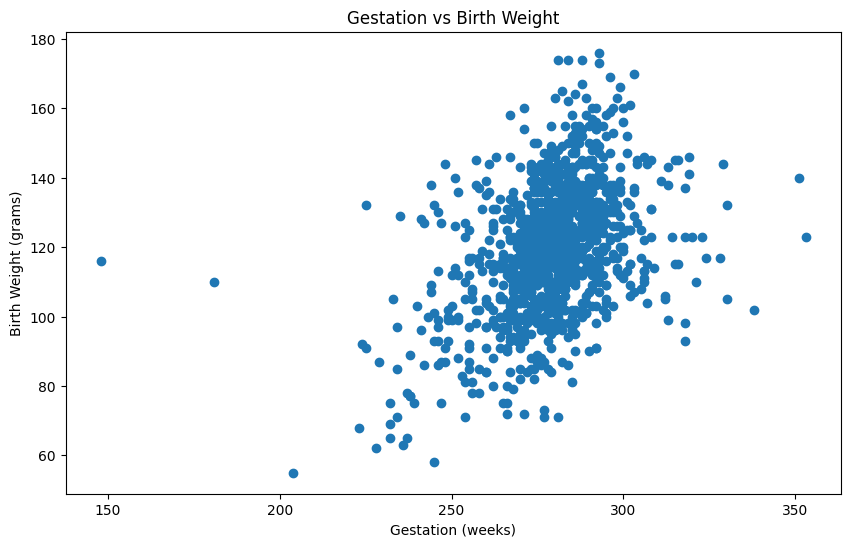

In [86]:
plt.figure(figsize=(10,6))
plt.scatter(df['gestation'], df['bwt'])
plt.xlabel('Gestation (weeks)')
plt.ylabel('Birth Weight (grams)')
plt.title('Gestation vs Birth Weight')
plt.show()

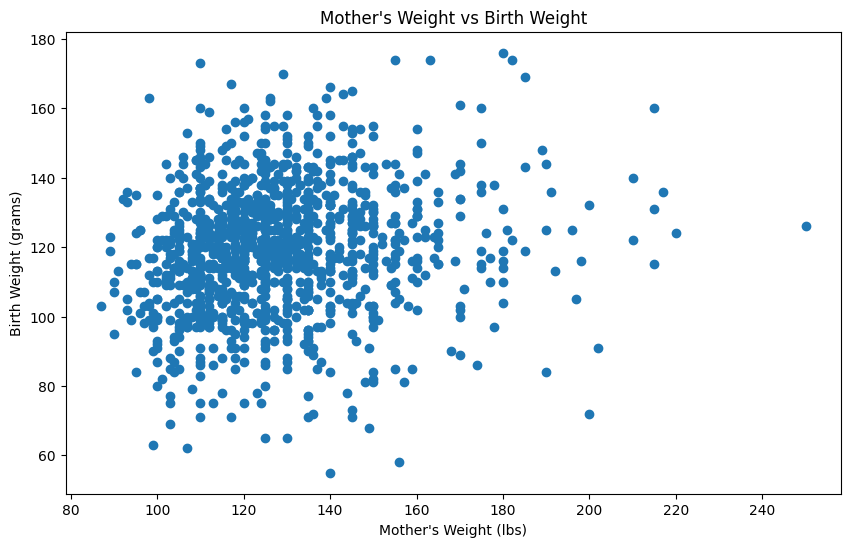

In [87]:
plt.figure(figsize=(10,6))
plt.scatter(df['weight'], df['bwt'])
plt.xlabel('Mother\'s Weight (lbs)')
plt.ylabel('Birth Weight (grams)')
plt.title('Mother\'s Weight vs Birth Weight')
plt.show()

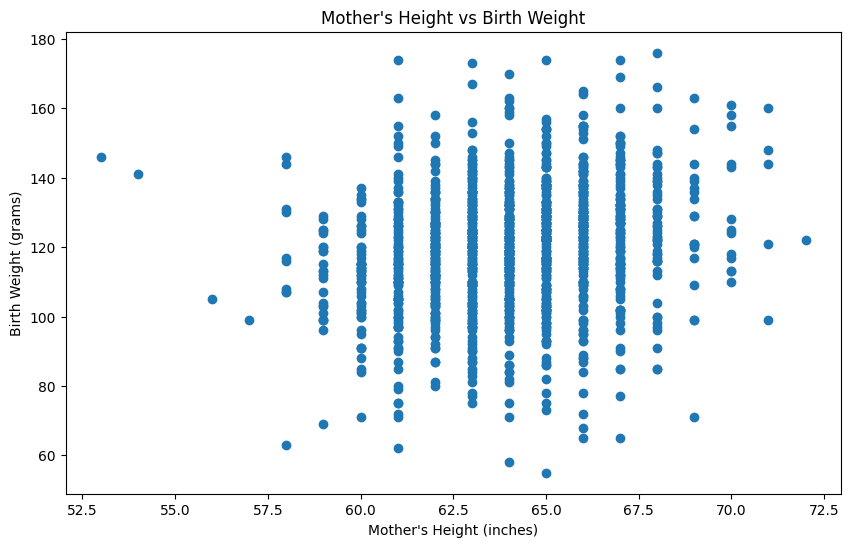

In [88]:
plt.figure(figsize=(10,6))
plt.scatter(df['height'], df['bwt'])
plt.xlabel('Mother\'s Height (inches)')
plt.ylabel('Birth Weight (grams)')
plt.title('Mother\'s Height vs Birth Weight')
plt.show()

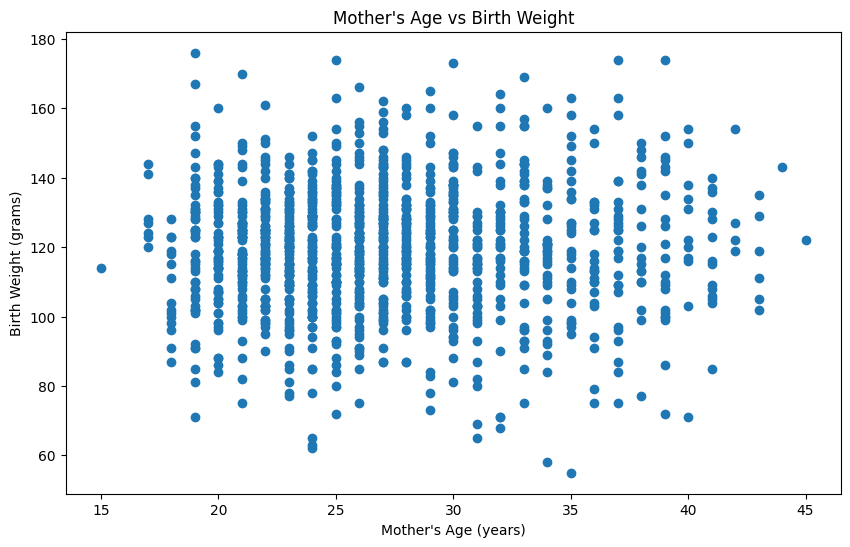

In [89]:
plt.figure(figsize=(10,6))
plt.scatter(df['age'], df['bwt'])
plt.xlabel('Mother\'s Age (years)')
plt.ylabel('Birth Weight (grams)')
plt.title('Mother\'s Age vs Birth Weight')
plt.show()

In [90]:
df['smoke'].value_counts()

smoke
0.0    715
1.0    459
Name: count, dtype: int64

In [91]:
df['smoke'].value_counts(normalize=True)*100

smoke
0.0    60.902896
1.0    39.097104
Name: proportion, dtype: float64

In [92]:
df['parity'].value_counts()

parity
0    866
1    308
Name: count, dtype: int64

In [93]:
df['parity'].value_counts(normalize=True)*100

parity
0    73.764906
1    26.235094
Name: proportion, dtype: float64

In [94]:
df.corr()

,bwt,gestation,parity,age,height,weight,smoke
bwt,1.000000,0.407543,-0.043908,0.026983,0.203704,0.155923,-0.246800
gestation,0.407543,1.000000,0.080916,-0.053425,0.070470,0.023655,-0.060267
parity,-0.043908,0.080916,1.000000,-0.351041,0.043543,-0.096362,-0.009599
age,0.026983,-0.053425,-0.351041,1.000000,-0.006453,0.147322,-0.067772
height,0.203704,0.070470,0.043543,-0.006453,1.000000,0.435287,0.017507
weight,0.155923,0.023655,-0.096362,0.147322,0.435287,1.000000,-0.060281
smoke,-0.246800,-0.060267,-0.009599,-0.067772,0.017507,-0.060281,1.000000


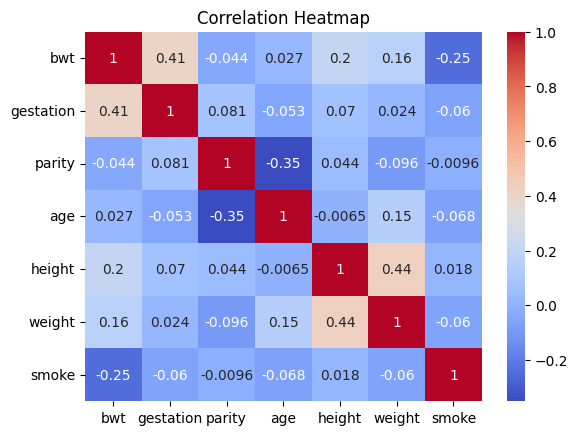

In [95]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [96]:
df.head()

,bwt,gestation,parity,age,height,weight,smoke
0,120,284.0,0,27.0,62.0,100.0,0.0
1,113,282.0,0,33.0,64.0,135.0,0.0
2,128,279.0,0,28.0,64.0,115.0,1.0
4,108,282.0,0,23.0,67.0,125.0,1.0
5,136,286.0,0,25.0,62.0,93.0,0.0


# Split the dataset into x and y

In [97]:
x =df.iloc[:,1:]
y = df['bwt']

# Train - Test data

In [98]:
import sklearn
from sklearn.model_selection import train_test_split

In [99]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [100]:
x_train.shape, x_test.shape

((939, 6), (235, 6))

In [101]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Train and Predict the Model

In [102]:
linear_model = LinearRegression()
ridge_model = Ridge()
lasso_model = Lasso()

In [103]:
linear_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [104]:
ridge_model.fit(x_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [105]:
lasso_model.fit(x_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [106]:
lr_pred = linear_model.predict(x_test)
ridge_pred = ridge_model.predict(x_test)
lasso_pred = lasso_model.predict(x_test)

# Model Evaluation

In [107]:
from sklearn.metrics import mean_squared_error, r2_score

lr_mse = mean_squared_error(y_test, lr_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)


In [108]:
lr_score = r2_score(y_test, lr_pred)
ridge_score = r2_score(y_test, ridge_pred)
lasso_score = r2_score(y_test, lasso_pred)

In [109]:
print("\n Performance of Linear Regression Model:")
print(f"Mean Squared Error: {lr_mse}")
print("R2score:", lr_score)
print("\n Performance of Ridge Regression Model:")
print(f"Mean Squared Error: {ridge_mse}")
print("R2score: ", ridge_score)
print("\n Performance of Lasso Regression Model:")
print(f"Mean Squared Error: {lasso_mse}")
print("R2score: ", lasso_score)


 Performance of Linear Regression Model:
Mean Squared Error: 259.48024931109904
R2score: 0.3391948868635133

 Performance of Ridge Regression Model:
Mean Squared Error: 259.5597897555019
R2score:  0.3389923252716306

 Performance of Lasso Regression Model:
Mean Squared Error: 278.05035399976265
R2score:  0.2919033486353515


# Selected model is Linear Regression

# Save the model

In [ ]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(linear_model, f)

# Load the pickle file

In [111]:
with open('model/model.pkl', 'rb') as obj:
    my_model = pickle.load(obj)

In [112]:
x_train.head()

,gestation,parity,age,height,weight,smoke
914,277.0,1,19.0,62.0,160.0,0.0
282,292.0,0,33.0,62.0,118.0,1.0
632,293.0,1,19.0,68.0,180.0,0.0
200,268.0,0,19.0,63.0,140.0,0.0
687,277.0,0,34.0,66.0,140.0,0.0


In [117]:
test_data = {
'gestation': [277.0],
'parity': [1],
'age': [19.0],
'height': [62.0],
'weight': [160.0],
'smoke': [0.0]
}

In [118]:
test_df = pd.DataFrame(test_data)
test_df

,gestation,parity,age,height,weight,smoke
0,277.0,1,19.0,62.0,160.0,0.0


In [119]:
my_model.predict(test_df)

array([120.17171151])